[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AIPI-590-XAI/Duke-AI-XAI/blob/main/assignments/xai_decathlon.ipynb)

# XAI Decathlon: Round 1 Individual Method Trial

In this lab, each student works with **one assigned explainability method** and tries to use it across ten explanation events.

The notebook gives you:

- Two trained target models: one tabular model and one image model.
- Ten event prompts with ready-to-use model objects, data objects, and assigned cases.
- A markdown results table to fill in as you go.
- A final model-profile prompt for summarizing what your method can and cannot support.

The notebook does **not** implement LIME, SHAP, PDP, ALE, Grad-CAM, Score-CAM, saliency, counterfactuals, or any other explanation method for you. That is the challenge.

**Estimated time:** 60-75 minutes  
**Format:** individual method trial  
**Deliverable:** a completed results table plus a short model profile


## Core Lesson

Different explanation methods answer different kinds of questions.

Your job is to find out where your assigned method is useful, where it is only partially useful, and where it simply does not fit the task. A method can earn a strong score for saying something clear and justified, including: "this method cannot answer this event question."

This notebook is intentionally only the individual round. Later, you may compare results with classmates who used different methods.


## Scoring Rules

For each event, assign your method one medal:

- **Gold:** directly answers the event question with convincing evidence.
- **Silver:** gives useful partial evidence, but another method or assumption is needed.
- **Bronze:** gives weak, indirect, or fragile evidence.
- **DNF:** does not finish: the method is mismatched, misleading, or not usable for the event.

A pretty visualization is not automatically a medal. Score the method based on whether it answers the event question.


## The Ten Events

| Event | Question |
|---|---|
| 1. Most Important Feature | What variable most strongly influences the tabular model's predictions? |
| 2. One Specific Prediction | Why did this individual tabular prediction occur? |
| 3. Dataset Bias or Shortcut | Is the image model relying on a spurious shortcut? |
| 4. Global Feature Effect | As one tabular feature changes, what happens to predictions? |
| 5. Compare Two Predictions | Why were two cases classified differently? |
| 6. Feature Interactions | Which tabular variables work together? |
| 7. Where Is the Model Looking? | What region of an image drives the prediction? |
| 8. Explain a Failure | Why did the model make this mistake? |
| 9. Estimate Trustworthiness | Should a human trust this prediction? |
| 10. Reverse Engineer Strategy | What strategy has each model learned? |

## Results Table

Edit this markdown cell as you work through the events. Keep each evidence claim short enough that someone else can understand what your method showed and why you assigned the medal.

**My assigned method:** Grad-CAM

| Event | Question | Medal | Evidence from my method | Limitations or notes |
|---|---|---|---|---|
| 1. Most Important Feature | What variable most strongly influences the tabular model's predictions? | TODO |  |  |
| 2. One Specific Prediction | Why did this individual tabular prediction occur? | TODO |  |  |
| 3. Dataset Bias or Shortcut | Is the image model relying on a spurious shortcut? | TODO |  |  |
| 4. Global Feature Effect | As one tabular feature changes, what happens to predictions? | TODO |  |  |
| 5. Compare Two Predictions | Why were two cases classified differently? | TODO |  |  |
| 6. Feature Interactions | Which tabular variables work together? | DNF | No Grad-CAM interaction output: the target is a random forest without convolutional feature maps or the required class-score gradients. | Cannot identify tabular interactions; would need a separate interaction analysis of the fitted risk model. |
| 7. Where Is the Model Looking? | What region of an image drives the prediction? | Gold | Predicted-class Grad-CAM highlights the upper-left marker in all three marker-present cases; the marker-absent case highlights shape edges and image borders more diffusely. | Coarse positive-evidence localization; per-image normalization and regional averages do not establish causal importance. |
| 8. Explain a Failure | Why did the model make this mistake? | Silver | A circle is predicted as square (P = 0.980); its square-class CAM concentrates on the red marker (mean 0.712 versus shape 0.119). The true-class CAM is blank. | Suggests a shortcut-driven error; Grad-CAM alone cannot confirm causality, and a blank map does not prove absence of shape information. |
| 9. Estimate Trustworthiness | Should a human trust this prediction? | Silver | Withhold trust: the CAM highlights the marker despite a square probability near 0.980; five small-noise trials retain the prediction and marker-focused map. The known circle label confirms the error. | Stable explanations can reflect a shortcut; Grad-CAM does not measure calibrated correctness or establish general robustness. |
| 10. Reverse Engineer Strategy | What strategy has each model learned? | Silver | Events 7–9 suggest marker-supported square predictions in selected images, including confident errors stable under small noise. Grad-CAM cannot profile the tabular random forest. | Partial image-strategy hypothesis; selected cases and repeated analysis of one failure do not establish a global or causal decision rule. |


In [1]:
#@title Setup
# Run this cell first. It imports only the libraries needed to create the target models.
# You may add your own XAI imports later in the "Your method implementation" section.

import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

SEED = 42
rng = np.random.default_rng(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cpu


In [2]:
#@title Event guide helper
# This table points you to the model/data objects for each event.

EVENTS = [
    "1. Most important feature",
    "2. One specific prediction",
    "3. Dataset bias or shortcut",
    "4. Global feature effect",
    "5. Compare two predictions",
    "6. Feature interactions",
    "7. Where is the model looking?",
    "8. Explain a failure",
    "9. Estimate trustworthiness",
    "10. Reverse engineer strategy",
]

event_guide = pd.DataFrame({
    "event": EVENTS,
    "target": [
        "Tabular risk model",
        "Tabular risk model",
        "Image shortcut model",
        "Tabular risk model",
        "Tabular or image cases",
        "Tabular risk model",
        "Image shortcut model",
        "Tabular or image failure case",
        "Either target model",
        "Both target models",
    ],
    "primary_objects": [
        "risk_model, X_train, X_test, feature_names, predict_risk_proba",
        "tabular_local_case, X_test, predict_risk_proba",
        "image_shortcut_case, image_reference_case, test_imgs, predict_image_proba",
        "X_train, X_test, feature_names, predict_risk_proba",
        "tabular_low_case vs tabular_high_case, or assigned_image_cases",
        "X_train, X_test, feature_names, predict_risk_proba",
        "image_model, test_imgs, assigned_image_cases, show_image_case",
        "tabular_failure_case or image_failure_case",
        "assigned cases, predicted probabilities, explanation stability checks",
        "all model interfaces and prior event evidence",
    ],
    "question_type": [
        "global feature importance",
        "local prediction explanation",
        "shortcut or bias diagnosis",
        "global feature effect",
        "contrastive explanation",
        "interaction discovery",
        "spatial localization",
        "failure diagnosis",
        "trust and uncertainty judgment",
        "synthesis and model profiling",
    ],
})

event_guide


,event,target,primary_objects,question_type
0,1. Most important feature,Tabular risk model,"risk_model, X_train, X_test, feature_names, pr...",global feature importance
1,2. One specific prediction,Tabular risk model,"tabular_local_case, X_test, predict_risk_proba",local prediction explanation
2,3. Dataset bias or shortcut,Image shortcut model,"image_shortcut_case, image_reference_case, tes...",shortcut or bias diagnosis
3,4. Global feature effect,Tabular risk model,"X_train, X_test, feature_names, predict_risk_p...",global feature effect
4,5. Compare two predictions,Tabular or image cases,"tabular_low_case vs tabular_high_case, or assi...",contrastive explanation
5,6. Feature interactions,Tabular risk model,"X_train, X_test, feature_names, predict_risk_p...",interaction discovery
6,7. Where is the model looking?,Image shortcut model,"image_model, test_imgs, assigned_image_cases, ...",spatial localization
7,8. Explain a failure,Tabular or image failure case,tabular_failure_case or image_failure_case,failure diagnosis
8,9. Estimate trustworthiness,Either target model,"assigned cases, predicted probabilities, expla...",trust and uncertainty judgment
9,10. Reverse engineer strategy,Both target models,all model interfaces and prior event evidence,synthesis and model profiling


# Target Model 1: Tabular Risk Model

You are given a trained model that predicts whether a synthetic applicant is **high risk**.

The model sees these features:

- `age`
- `income_k`
- `debt_ratio`
- `loyalty_years`
- `recent_late_payments`
- `savings_k`
- `app_minutes`
- `support_tickets`
- `zip_proxy`
- `promo_seen`

Treat this as a model you need to investigate. Some variables are directly meaningful, some are weak, some may act like shortcuts, and some may interact.

In [3]:
#@title Create the tabular data and train the risk model

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def make_tabular_data(n=3000, seed=SEED):
    rng = np.random.default_rng(seed)
    age = rng.integers(18, 76, size=n)
    income_k = np.clip(rng.normal(72, 24, size=n), 18, 180)
    debt_ratio = np.clip(rng.beta(2.2, 5.0, size=n), 0.01, 0.98)
    loyalty_years = np.clip((age - 18) * rng.beta(1.5, 6.0, size=n), 0, 35)
    recent_late_payments = rng.poisson(0.65 + 1.8 * debt_ratio, size=n)
    savings_k = np.clip(rng.lognormal(mean=2.35, sigma=0.8, size=n), 0, 120)
    app_minutes = np.clip(rng.normal(18, 7, size=n), 2, 60)
    support_tickets = rng.poisson(0.3 + 0.5 * (debt_ratio > 0.45), size=n)

    zip_proxy = rng.binomial(1, sigmoid(-0.9 + 1.9 * debt_ratio - 0.012 * income_k), size=n)
    promo_seen = rng.binomial(1, sigmoid(-0.3 + 1.4 * zip_proxy + 0.8 * (age < 30)), size=n)
    young_high_debt = ((age < 30) & (debt_ratio > 0.48)).astype(float)

    logit = (
        -1.9
        + 3.8 * debt_ratio
        + 0.38 * recent_late_payments
        - 0.018 * income_k
        - 0.024 * savings_k
        - 0.045 * loyalty_years
        + 0.85 * zip_proxy
        + 0.55 * promo_seen
        + 1.25 * young_high_debt
        + 0.025 * support_tickets
        + rng.normal(0, 0.45, size=n)
    )
    p = sigmoid(logit)
    y = rng.binomial(1, p)

    X = pd.DataFrame({
        "age": age,
        "income_k": income_k,
        "debt_ratio": debt_ratio,
        "loyalty_years": loyalty_years,
        "recent_late_payments": recent_late_payments,
        "savings_k": savings_k,
        "app_minutes": app_minutes,
        "support_tickets": support_tickets,
        "zip_proxy": zip_proxy,
        "promo_seen": promo_seen,
    })
    return X, pd.Series(y, name="high_risk")

X, y = make_tabular_data()
feature_names = X.columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

risk_model = RandomForestClassifier(
    n_estimators=220,
    max_depth=7,
    min_samples_leaf=12,
    random_state=SEED,
    n_jobs=-1,
)
risk_model.fit(X_train, y_train)

tabular_pred = risk_model.predict(X_test)
tabular_proba = risk_model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, tabular_pred), 3))
print("Positive class rate in test set:", round(float(y_test.mean()), 3))
print(classification_report(y_test, tabular_pred, target_names=["low risk", "high risk"]))
X_train.head()

Accuracy: 0.805
Positive class rate in test set: 0.224
              precision    recall  f1-score   support

    low risk       0.81      0.97      0.89       582
   high risk       0.70      0.23      0.34       168

    accuracy                           0.81       750
   macro avg       0.76      0.60      0.61       750
weighted avg       0.79      0.81      0.76       750



,age,income_k,debt_ratio,loyalty_years,recent_late_payments,savings_k,app_minutes,support_tickets,zip_proxy,promo_seen
1583,42,60.186070,0.178157,3.750431,2,12.938567,8.853330,1,0,1
1035,61,125.055381,0.136064,3.955724,0,7.920787,8.808620,0,0,1
657,54,74.580820,0.488986,16.918809,1,2.733885,18.188498,0,0,0
968,71,71.595919,0.282121,7.306052,0,2.729296,19.732005,1,0,1
2298,30,81.528758,0.200992,0.374701,2,4.948344,13.871067,0,1,1


In [4]:
#@title Tabular model interface and assigned cases
# These are allowed utilities. They expose the model and selected cases, but they do not explain the model.

def predict_risk_proba(data):
    """Return [P(low risk), P(high risk)] for rows with the tabular feature columns."""
    if isinstance(data, pd.DataFrame):
        df = data[feature_names]
    else:
        df = pd.DataFrame(data, columns=feature_names)
    return risk_model.predict_proba(df)

def first_distinct(candidates, used=(), fallback=0):
    """Pick the first candidate that is not already used."""
    for idx in candidates:
        idx = int(idx)
        if idx not in used:
            return idx
    return int(fallback)

# Cases for local, comparison, and failure events.
tabular_low_case = int(np.argmin(tabular_proba))
tabular_high_case = int(np.argmax(tabular_proba))
near_boundary_rows = np.argsort(np.abs(tabular_proba - 0.5))
tabular_local_case = first_distinct(near_boundary_rows, used={tabular_low_case, tabular_high_case})
wrong_rows = np.where(tabular_pred != y_test.to_numpy())[0]
tabular_failure_case = first_distinct(
    wrong_rows,
    used={tabular_local_case, tabular_low_case, tabular_high_case},
    fallback=tabular_local_case,
)

assigned_tabular_cases = pd.DataFrame({
    "case_name": ["local_case", "low_case", "high_case", "failure_case"],
    "row_index_in_X_test": [tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case],
    "true_label": [
        int(y_test.iloc[tabular_local_case]),
        int(y_test.iloc[tabular_low_case]),
        int(y_test.iloc[tabular_high_case]),
        int(y_test.iloc[tabular_failure_case]),
    ],
    "predicted_label": [
        int(tabular_pred[tabular_local_case]),
        int(tabular_pred[tabular_low_case]),
        int(tabular_pred[tabular_high_case]),
        int(tabular_pred[tabular_failure_case]),
    ],
    "predicted_P_high_risk": [
        round(float(tabular_proba[tabular_local_case]), 3),
        round(float(tabular_proba[tabular_low_case]), 3),
        round(float(tabular_proba[tabular_high_case]), 3),
        round(float(tabular_proba[tabular_failure_case]), 3),
    ],
})

assigned_tabular_cases

,case_name,row_index_in_X_test,true_label,predicted_label,predicted_P_high_risk
0,local_case,718,0,0,0.499
1,low_case,565,0,0,0.022
2,high_case,564,1,1,0.789
3,failure_case,1,1,0,0.400


# Target Model 2: Image Shortcut Model

You are given a tiny image classifier trained on synthetic images.

- Class `0`: circle
- Class `1`: square

The training data may contain a shortcut. The test set is designed so you can investigate whether the model learned the intended shape concept, a shortcut, or both.

In [5]:
#@title Create the image data and train the image model

def draw_shape_image(label, marker=None, seed=None, image_size=64):
    rng = np.random.default_rng(seed)
    img = np.ones((image_size, image_size, 3), dtype=np.float32) * 0.92
    img += rng.normal(0, 0.025, size=img.shape).astype(np.float32)
    img = np.clip(img, 0, 1)

    yy, xx = np.mgrid[:image_size, :image_size]
    cx = image_size // 2 + int(rng.integers(-5, 6))
    cy = image_size // 2 + int(rng.integers(-5, 6))

    color = np.array([0.20, 0.22, 0.24])
    if label == 0:
        radius = int(rng.integers(10, 18))
        mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= radius ** 2
    else:
        half = int(rng.integers(9, 17))
        mask = (np.abs(xx - cx) <= half) & (np.abs(yy - cy) <= half)

    img[mask] = color

    # The marker is part of the data-generation process. Whether it is fair evidence is for you to investigate.
    if marker is None:
        marker = rng.random() < (0.98 if label == 1 else 0.02)
    if marker:
        img[3:15, 3:15, :] = np.array([0.95, 0.08, 0.08])

    return np.clip(img, 0, 1), int(marker)


def make_image_dataset(n=800, seed=SEED, balanced_markers=False):
    rng = np.random.default_rng(seed)
    images, labels, markers = [], [], []
    for i in range(n):
        label = int(rng.integers(0, 2))
        marker = None
        if balanced_markers:
            marker = bool(rng.integers(0, 2))
        img, has_marker = draw_shape_image(label, marker=marker, seed=seed + i)
        images.append(img)
        labels.append(label)
        markers.append(has_marker)
    return np.stack(images), np.array(labels), np.array(markers)

train_imgs, train_y, train_marker = make_image_dataset(800, seed=10, balanced_markers=False)
test_imgs, test_y, test_marker = make_image_dataset(320, seed=5000, balanced_markers=True)

class TinyShapeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 12, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(12, 24, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(24 * 16 * 16, 48)
        self.fc2 = nn.Linear(48, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


def to_tensor_images(images):
    return torch.tensor(images.transpose(0, 3, 1, 2), dtype=torch.float32)

train_ds = TensorDataset(to_tensor_images(train_imgs), torch.tensor(train_y, dtype=torch.long))
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

image_model = TinyShapeCNN().to(DEVICE)
optimizer = torch.optim.Adam(image_model.parameters(), lr=1e-3)

image_model.train()
for epoch in range(4):
    losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = F.cross_entropy(image_model(xb), yb)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach().cpu()))
    print(f"epoch {epoch + 1}: loss={np.mean(losses):.4f}")

image_model.eval()
with torch.no_grad():
    logits = image_model(to_tensor_images(test_imgs).to(DEVICE))
    image_proba = F.softmax(logits, dim=1).cpu().numpy()
    image_pred = image_proba.argmax(axis=1)

print("Test accuracy:", round(accuracy_score(test_y, image_pred), 3))
print("Confusion matrix:\n", confusion_matrix(test_y, image_pred))

epoch 1: loss=0.6577
epoch 2: loss=0.2582
epoch 3: loss=0.0858
epoch 4: loss=0.0954
Test accuracy: 0.494
Confusion matrix:
 [[68 84]
 [78 90]]


In [6]:
#@title Image model interface and assigned cases
# These are allowed utilities. They expose the model and selected cases, but they do not explain the model.

def predict_image_proba(images_np):
    """Return [P(circle), P(square)] for images shaped as N x 64 x 64 x 3."""
    image_model.eval()
    with torch.no_grad():
        xb = to_tensor_images(np.asarray(images_np)).to(DEVICE)
        probs = F.softmax(image_model(xb), dim=1).cpu().numpy()
    return probs


def show_image_case(idx, title_prefix=""):
    probs = predict_image_proba(test_imgs[[idx]])[0]
    plt.imshow(test_imgs[idx])
    plt.axis("off")
    plt.title(
        f"{title_prefix}idx={idx} true={test_y[idx]} pred={probs.argmax()} "
        f"P(square)={probs[1]:.3f} marker={test_marker[idx]}"
    )
    plt.show()

def first_distinct(candidates, used=(), fallback=0):
    """Pick the first candidate that is not already used."""
    for idx in candidates:
        idx = int(idx)
        if idx not in used:
            return idx
    return int(fallback)

image_wrong = np.where(image_pred != test_y)[0]
marker_present_circle = np.where((test_marker == 1) & (test_y == 0))[0]
marker_present_square = np.where((test_marker == 1) & (test_y == 1))[0]
marker_absent_square = np.where((test_marker == 0) & (test_y == 1))[0]
image_shortcut_case = first_distinct(marker_present_circle, fallback=0)
image_reference_case = first_distinct(marker_present_square, used={image_shortcut_case}, fallback=0)
image_contrast_case = first_distinct(
    marker_absent_square,
    used={image_shortcut_case, image_reference_case},
    fallback=1,
)
image_failure_case = first_distinct(
    image_wrong,
    used={image_shortcut_case, image_reference_case, image_contrast_case},
    fallback=image_contrast_case,
)

assigned_image_cases = pd.DataFrame({
    "case_name": ["shortcut_probe", "reference_square", "contrast_square", "failure_case"],
    "image_index": [image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case],
    "true_label": [
        int(test_y[image_shortcut_case]),
        int(test_y[image_reference_case]),
        int(test_y[image_contrast_case]),
        int(test_y[image_failure_case]),
    ],
    "marker_present": [
        int(test_marker[image_shortcut_case]),
        int(test_marker[image_reference_case]),
        int(test_marker[image_contrast_case]),
        int(test_marker[image_failure_case]),
    ],
    "predicted_label": [
        int(image_pred[image_shortcut_case]),
        int(image_pred[image_reference_case]),
        int(image_pred[image_contrast_case]),
        int(image_pred[image_failure_case]),
    ],
    "predicted_P_square": [
        round(float(image_proba[image_shortcut_case, 1]), 3),
        round(float(image_proba[image_reference_case, 1]), 3),
        round(float(image_proba[image_contrast_case, 1]), 3),
        round(float(image_proba[image_failure_case, 1]), 3),
    ],
})

assigned_image_cases

,case_name,image_index,true_label,marker_present,predicted_label,predicted_P_square
0,shortcut_probe,5,0,1,1,0.980
1,reference_square,2,1,1,1,0.985
2,contrast_square,4,1,0,0,0.066
3,failure_case,6,0,1,1,0.980


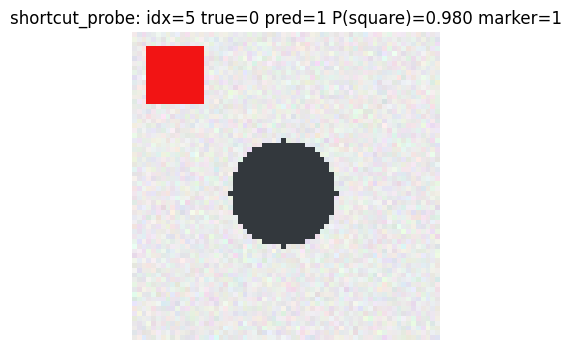

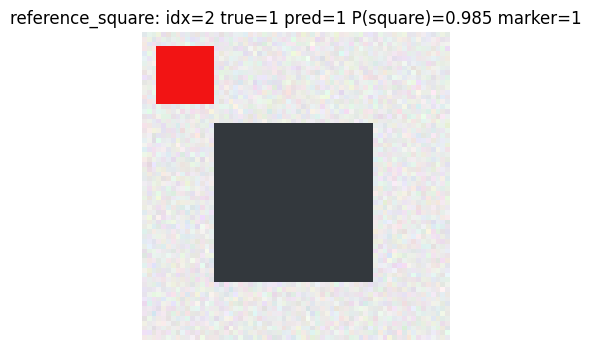

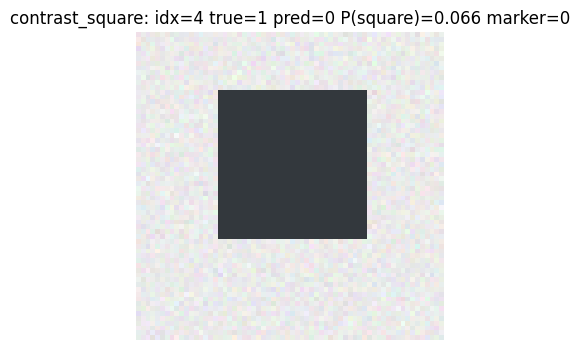

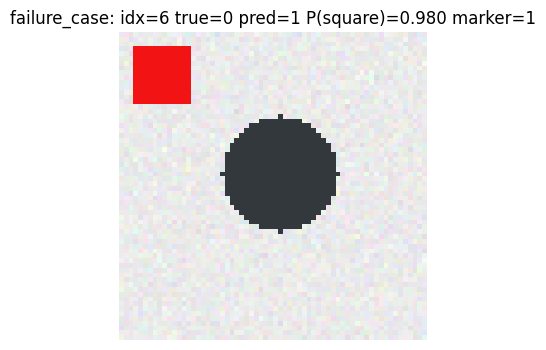

In [7]:
#@title View the assigned image cases
for name, idx in zip(assigned_image_cases["case_name"], assigned_image_cases["image_index"]):
    show_image_case(int(idx), title_prefix=f"{name}: ")

# Your Method Implementation

Use this section to install packages, import libraries, write helper functions, and adapt your assigned XAI method.

You may use external documentation. You may also decide that your method cannot reasonably be applied to an event, but you must explain why.

Suggested workflow:

1. Identify what inputs your method needs: tabular rows, images, gradients, model probabilities, labels, background data, perturbed samples, etc.
2. Decide whether your method is local, global, visual, counterfactual, or something else.
3. Implement the smallest version that can answer one event.
4. Reuse and adapt it across events.
5. Record both successes and failures honestly.


In [ ]:
# Your implementation scratchpad.
# Add imports, installations, helper functions, and experiments here.

# Examples of things you might add in Colab, depending on your method:
# !pip install shap lime captum torchcam alibi PyALE
# import shap
# from lime.lime_tabular import LimeTabularExplainer

print("Event guide:")
display(event_guide)

# Keep your method-specific code here or add new cells below.


## Individual Event Checklist

For each event, produce four things:

- **Output:** the plot, table, heatmap, counterfactual, ranking, or diagnostic your method produced.
- **Claim:** one sentence answering the event question, or saying the method cannot answer it.
- **Evidence quality:** why the output does or does not support the claim.
- **Medal:** Gold, Silver, Bronze, or DNF.

After each event, fill in the markdown Results Table near the top of the notebook. A DNF is not a failure of the student. It is evidence about the method's scope.


## Event 1: Find the Most Important Feature

**Question:** What variable most strongly influences the tabular model's predictions?

**Target:** Tabular risk model

**Your task:** Produce evidence that ranks or compares the influence of multiple features. If your method cannot produce global feature importance, explain the mismatch.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [ ]:
# Event 1 workspace: implement or adapt YOUR assigned method here.
# Add as many cells as you need. This placeholder is intentionally not an explanation.

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 2: Explain One Specific Prediction

**Question:** Why did this individual tabular prediction occur?

**Target:** Tabular local case

**Your task:** Use `tabular_local_case` and explain the model's prediction for that row. Your answer should refer to row-specific evidence.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [ ]:
# Event 2 workspace: implement or adapt YOUR assigned method here.
# Add as many cells as you need. This placeholder is intentionally not an explanation.

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 3: Detect Dataset Bias or a Shortcut

**Question:** Is the image model relying on a spurious shortcut?

**Target:** Image shortcut probe

**Your task:** Investigate whether the classifier uses the red corner marker, the shape, or both. Your method may need adaptation if it is not an image method.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [ ]:
# Event 3 workspace: implement or adapt YOUR assigned method here.
# Add as many cells as you need. This placeholder is intentionally not an explanation.

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 4: Understand a Feature's Global Effect

**Question:** As one tabular feature changes, what happens to predictions?

**Target:** Tabular risk model

**Your task:** Choose a feature such as `debt_ratio`, `income_k`, or `age`. Show how predictions change as that feature changes, or explain why your method cannot answer a global effect question.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [ ]:
# Event 4 workspace: implement or adapt YOUR assigned method here.
# Add as many cells as you need. This placeholder is intentionally not an explanation.

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 5: Compare Two Predictions

**Question:** Why were two cases classified differently?

**Target:** Tabular or image comparison cases

**Your task:** Compare `tabular_low_case` vs. `tabular_high_case`, or compare two assigned image cases. Explain the difference, not just each case separately.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [ ]:
# Event 5 workspace: implement or adapt YOUR assigned method here.
# Add as many cells as you need. This placeholder is intentionally not an explanation.

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 6: Detect Feature Interactions

**Question:** Which tabular variables work together?

**Target:** Tabular risk model

**Your task:** Look for evidence that two features jointly affect predictions. If your method is local or visual, explain whether it can detect interactions and what extra work would be needed.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

### Event 6 result — Grad-CAM

**Output:** Not applicable. No Grad-CAM heatmap or interaction scores were produced for this event. The target, `risk_model`, is a scikit-learn `RandomForestClassifier` operating on tabular features.

**Claim:** Grad-CAM cannot determine which tabular variables work together in this model.

**Evidence quality:** Grad-CAM weights convolutional feature maps using gradients of a target class score with respect to those maps. This random forest has neither convolutional feature maps nor the differentiable computation required by Grad-CAM. This is an architectural mismatch, not an unsuccessful experiment. It does not imply that the random forest has no interactions.

Even on the compatible image model, a Grad-CAM heatmap localizes spatial evidence supporting a class; two highlighted regions do not establish an interaction. An interaction requires evidence that the effect of one feature depends on the value of another. Applying Grad-CAM to Model 2 would therefore not answer this event's tabular question.

**Medal: DNF.** The assigned method cannot supply evidence of interactions in the specified target model.

**What extra work would be needed?** A separate method could evaluate the fitted risk model on a two-feature grid and compare its joint prediction response with an additive combination of the individual feature effects, accounting for data support and feature dependence. A two-dimensional partial-dependence interaction analysis is one option. That would be additional evidence from another method, not a Grad-CAM result, and has not been performed here.

The data generator explicitly includes an `age`–`debt_ratio` interaction through `young_high_debt`. This suggests a candidate to investigate, but inspecting the data-generation rule does not establish that the trained random forest learned that interaction and is not evidence from Grad-CAM.


## Event 7: Find Where the Model Is Looking

**Question:** What region of an image drives the prediction?

**Target:** Image model

**Your task:** Use one or more assigned image cases. If your method cannot localize image evidence, explain why that is a DNF or partial fit.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

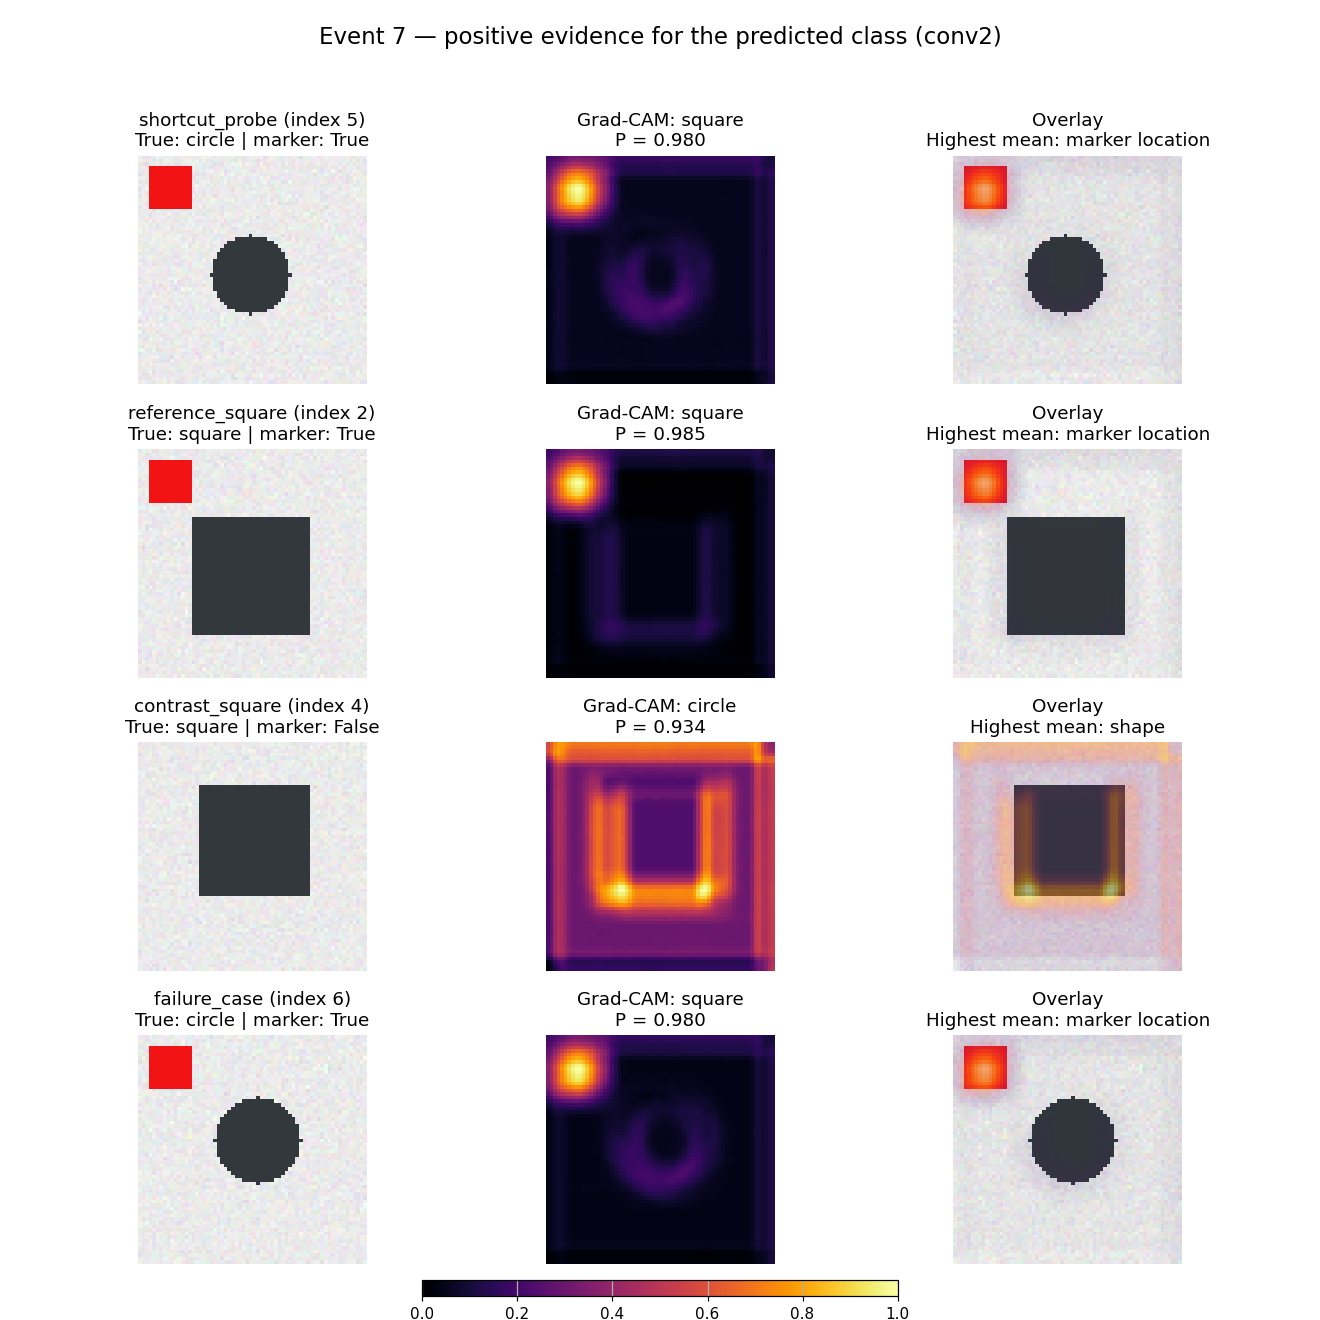

,case,index,true class,explained prediction,P(predicted class),marker present,mean CAM: marker location,mean CAM: shape,mean CAM: background,highest mean region
0,shortcut_probe,5,circle,square,0.980,True,0.715,0.130,0.091,marker location
1,reference_square,2,square,square,0.985,True,0.701,0.068,0.061,marker location
2,contrast_square,4,square,circle,0.934,False,0.438,0.442,0.416,shape
3,failure_case,6,circle,square,0.980,True,0.712,0.119,0.082,marker location


Region averages describe heatmap localization; they are not probabilities or causal effects.
Each map is normalized independently. A blank map means no positive Grad-CAM evidence, not no model reliance.


In [4]:
# Event 7: Grad-CAM for each assigned image's predicted class.
# Run Setup and the image-model/data/assigned-case cells first.
# Use logits directly: predict_image_proba disables gradients.

def grad_cam(model, image, target_layer, target_class=None):
    """Return a normalized positive-evidence map, probabilities, and target class."""
    activations = []
    handle = target_layer.register_forward_hook(
        lambda module, inputs, output: activations.append(output)
    )
    was_training = model.training
    try:
        model.eval()
        with torch.enable_grad():
            x = to_tensor_images(np.asarray(image)[None]).to(next(model.parameters()).device)
            x.requires_grad_(True)
            logits = model(x)
            chosen = int(logits.argmax(dim=1).item()) if target_class is None else int(target_class)
            features = activations[0]
            gradients = torch.autograd.grad(logits[0, chosen], features)[0]
            weights = gradients.mean(dim=(2, 3), keepdim=True)
            cam = F.relu((weights * features).sum(dim=1, keepdim=True))
            cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)
            cam = cam[0, 0].detach().cpu().numpy()
            peak = float(cam.max())
            if peak > 0:
                cam = cam / peak
            probabilities = logits.softmax(dim=1)[0].detach().cpu().numpy()
        return cam, probabilities, chosen
    finally:
        handle.remove()
        model.train(was_training)


class_names = ["circle", "square"]
event7_rows = []
event7_maps = {}
fig, axes = plt.subplots(len(assigned_image_cases), 3, figsize=(12, 12), squeeze=False)
for row, case in enumerate(assigned_image_cases.itertuples(index=False)):
    idx = int(case.image_index)
    img = test_imgs[idx]
    cam, probabilities, target = grad_cam(image_model, img, image_model.conv2)
    event7_maps[case.case_name] = cam

    # Known synthetic regions summarize the map, not causal feature importance.
    corner = np.zeros(cam.shape, dtype=bool)
    corner[3:15, 3:15] = True
    shape = (img.max(axis=2) < 0.4)
    background = ~(corner | shape)
    masks = {"marker location": corner, "shape": shape, "background": background}
    means = {name: float(cam[mask].mean()) for name, mask in masks.items()}
    strongest = max(means, key=means.get) if cam.max() > 0 else "no positive evidence"
    event7_rows.append({
        "case": case.case_name, "index": idx,
        "true class": class_names[int(test_y[idx])],
        "explained prediction": class_names[target],
        "P(predicted class)": float(probabilities[target]),
        "marker present": bool(test_marker[idx]),
        **{f"mean CAM: {name}": value for name, value in means.items()},
        "highest mean region": strongest,
    })
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"{case.case_name} (index {idx})\nTrue: {class_names[int(test_y[idx])]} | marker: {bool(test_marker[idx])}")
    heat = axes[row, 1].imshow(cam, cmap="inferno", vmin=0, vmax=1)
    axes[row, 1].set_title(f"Grad-CAM: {class_names[target]}\nP = {probabilities[target]:.3f}")
    axes[row, 2].imshow(img)
    axes[row, 2].imshow(cam, cmap="inferno", vmin=0, vmax=1, alpha=0.6 * cam)
    axes[row, 2].set_title(f"Overlay\nHighest mean: {strongest}")
    for ax in axes[row]:
        ax.axis("off")
fig.suptitle("Event 7 — positive evidence for the predicted class (conv2)", fontsize=15)
fig.tight_layout(rect=[0, 0.03, 1, 0.96])
colorbar_axis = fig.add_axes([0.32, 0.018, 0.36, 0.012])
fig.colorbar(heat, cax=colorbar_axis, orientation="horizontal", label="CAM intensity (normalized within each image)")
plt.show()
event7_summary = pd.DataFrame(event7_rows)
display(event7_summary.round(3))
print("Region averages describe heatmap localization; they are not probabilities or causal effects.")
print("Each map is normalized independently. A blank map means no positive Grad-CAM evidence, not no model reliance.")


### Event 7: Analysis of the Grad-CAM outputs

**Output and claim:** The heatmaps and overlays show where Grad-CAM finds positive evidence for each image's **predicted class**. In all three images containing a red marker, the strongest hotspot is in the upper-left marker region, with much weaker evidence on the central shape. The marker-absent image produces a more diffuse map around the shape edges and image border.

| Assigned case | Actual → predicted class | Predicted-class probability | Mean CAM: marker location | Mean CAM: shape | Mean CAM: background |
|---|---|---|---|---|---|---|
| Shortcut probe (5) | Circle → square | 0.980 | 0.715 | 0.130 | 0.091 |
| Reference square (2) | Square → square | 0.985 | 0.701 | 0.068 | 0.061 |
| Contrast square (4) | Square → circle | 0.934 | 0.438 | 0.442 | 0.416 |
| Failure case (6) | Circle → square | 0.980 | 0.712 | 0.119 | 0.082 |

**What the individual cases show:** The shortcut probe and failure case are circles classified as squares, and their square-class maps concentrate on the red marker. The correctly classified reference square shows the same pattern: the marker region is highlighted much more strongly than the square itself. Together, these examples suggest that the corner marker supplies supporting evidence for the square prediction, even when the actual shape is a circle. Correct classification of the reference square therefore does not, by itself, demonstrate that the model recognized its shape.

The contrast square has no marker and is incorrectly classified as a circle. Its map explains the **circle score**, unlike the other three maps, which explain the square score. The visualization highlights parts of the shape boundary and image border rather than a single clearly dominant region. Although the summary labels the shape as the highest-mean region, its mean of 0.442 is only slightly above the empty marker location (0.438) and background (0.416). This is weak evidence for selective focus on the shape, and it does not establish that the model recognized a circle or that marker absence caused the error.

**Evidence quality and limitations:** Grad-CAM directly addresses this event's spatial-localization question, and the agreement between the visible hotspots and regional averages supports the marker-localization claim. However, these are coarse maps of positive class-score evidence, not literal attention maps or proof of causal dependence. The convolutional map is upsampled, so highlighted regions can spill across boundaries. Intensities are normalized separately for each image; 0.715 is a normalized heatmap average, not a 71.5% contribution to the prediction. The maps also omit negative evidence, and comparing maps for different target classes requires care. A controlled perturbation experiment could test whether altering the marker or shape actually changes the prediction, which these heatmaps alone cannot establish.

**Medal: Gold.** Grad-CAM directly localizes supporting image evidence and gives clear, interpretable results for the three marker-present cases. The diffuse contrast case and the absence of causal testing limit the conclusions, but do not prevent the method from answering where supporting evidence is localized in these examples.


## Event 8: Explain a Failure

**Question:** Why did the model make this mistake?

**Target:** Tabular and/or image failure case

**Your task:** Use `tabular_failure_case` or `image_failure_case`. Explain the likely reason for the incorrect prediction using your method, or explain why it cannot diagnose a single failure.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

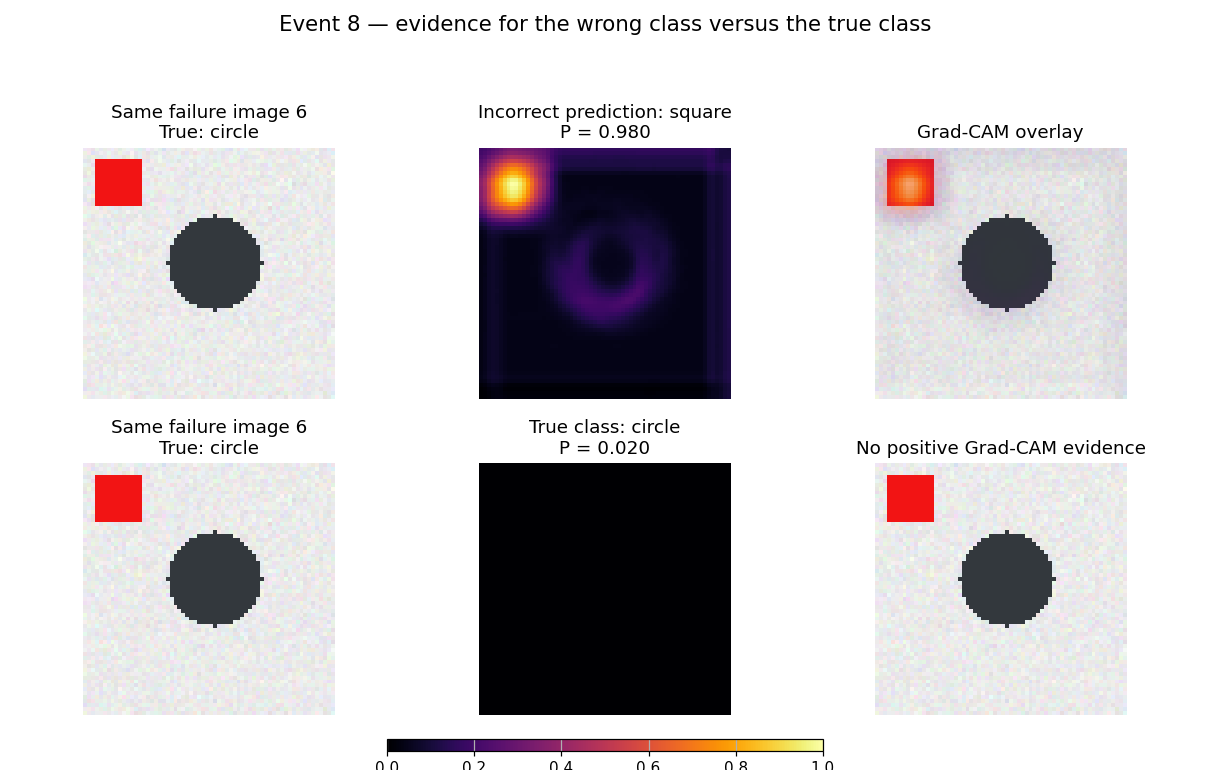

,explanation target,class,class probability,mean CAM: marker location,mean CAM: shape,mean CAM: background,positive map available
0,Incorrect prediction,square,0.98,0.712,0.119,0.082,True
1,True class,circle,0.02,0.000,0.000,0.000,False


Assigned failure: image 6; marker present: True
True class: circle; incorrect prediction: square
P(circle) = 0.020; P(square) = 0.980
Compare spatial patterns, not absolute intensity across class maps.
Grad-CAM suggests a reason for the failure; it does not prove a causal mechanism.


In [4]:
# Event 8: diagnose the assigned image failure using Grad-CAM.
# Run the image setup and Event 7 first (which defines grad_cam).
idx8 = int(image_failure_case)
img8 = test_imgs[idx8]
true8 = int(test_y[idx8])
pred_cam8, probs8, pred8 = grad_cam(image_model, img8, image_model.conv2)
if pred8 == true8:
    raise ValueError(
        "The assigned image_failure_case is correctly classified in this run. "
        "Inspect the assigned cases and select a genuinely misclassified image before diagnosing a failure."
    )
true_cam8, _, _ = grad_cam(image_model, img8, image_model.conv2, target_class=true8)

names8 = ["circle", "square"]
print(f"Assigned failure: image {idx8}; marker present: {bool(test_marker[idx8])}")
print(f"True class: {names8[true8]}; incorrect prediction: {names8[pred8]}")
print(f"P(circle) = {probs8[0]:.3f}; P(square) = {probs8[1]:.3f}")

corner8 = np.zeros(pred_cam8.shape, dtype=bool)
corner8[3:15, 3:15] = True
shape8 = img8.max(axis=2) < 0.4
regions8 = {"marker location": corner8, "shape": shape8, "background": ~(corner8 | shape8)}
rows8 = []
fig8, axes8 = plt.subplots(2, 3, figsize=(11, 7))
for row8, (label8, target8, cam8) in enumerate([
    ("Incorrect prediction", pred8, pred_cam8),
    ("True class", true8, true_cam8),
]):
    rows8.append({
        "explanation target": label8,
        "class": names8[target8],
        "class probability": float(probs8[target8]),
        **{f"mean CAM: {region}": float(cam8[mask].mean()) for region, mask in regions8.items()},
        "positive map available": bool(cam8.max() > 0),
    })
    axes8[row8, 0].imshow(img8)
    axes8[row8, 0].set_title(f"Same failure image {idx8}\nTrue: {names8[true8]}")
    heat8 = axes8[row8, 1].imshow(cam8, cmap="inferno", vmin=0, vmax=1)
    axes8[row8, 1].set_title(f"{label8}: {names8[target8]}\nP = {probs8[target8]:.3f}")
    axes8[row8, 2].imshow(img8)
    axes8[row8, 2].imshow(cam8, cmap="inferno", vmin=0, vmax=1, alpha=0.6 * cam8)
    axes8[row8, 2].set_title("Grad-CAM overlay" if cam8.max() > 0 else "No positive Grad-CAM evidence")
    for ax8 in axes8[row8]:
        ax8.axis("off")
fig8.suptitle("Event 8 — evidence for the wrong class versus the true class", fontsize=14)
fig8.tight_layout(rect=[0, 0.05, 1, 0.94])
colorbar8 = fig8.add_axes([0.32, 0.025, 0.36, 0.015])
fig8.colorbar(heat8, cax=colorbar8, orientation="horizontal", label="CAM intensity (each class map normalized separately)")
plt.show()
event8_summary = pd.DataFrame(rows8)
display(event8_summary.round(3))
print("Compare spatial patterns, not absolute intensity across class maps.")
print("Grad-CAM suggests a reason for the failure; it does not prove a causal mechanism.")


### Event 8: Analysis of the failure

**Output:** Grad-CAM heatmaps and overlays for both the incorrectly predicted class and the true class of `image_failure_case`, plus a table summarizing their spatial evidence. The cell checks that the assigned case is actually misclassified before diagnosing it. Run Event 7 first to define the shared `grad_cam` helper.

**Observed failure:** In this executed run, image 6 is a **circle with a red marker**, but the model predicts **square** with probability **0.980**; the circle probability is **0.020**.

**Claim:** The likely explanation is that the model uses the red corner marker as supporting evidence for the square class even though the central object is a circle. This is consistent with a shortcut-driven error, rather than successful recognition of the intended shape.

**Evidence from Grad-CAM:** The incorrect square-class map has a clear hotspot over the marker. Mean normalized CAM intensity is **0.712** in the marker location, compared with **0.119** inside the circle and **0.082** in the background. These values describe localization within this map; they are not percentages of responsibility for the error. The pattern agrees with Event 7, where the marker also dominated the square-class maps for the reference square and the other misclassified circle.

The true circle-class map is entirely zero. Grad-CAM applies ReLU to the gradient-weighted feature-map sum, so this means the chosen layer provides no positive localization under this calculation. It does **not** establish that the model has no circle-related features, that it ignores every shape pixel, or that there is no negative evidence. Because each class map is normalized independently when nonzero, the maps should be compared for spatial pattern, not absolute evidence strength.

**Evidence quality and limitations:** The wrong-class hotspot gives a plausible, case-specific reason for this mistake. However, Grad-CAM does not show that the marker caused the prediction, quantify how much it outweighed shape evidence, or establish the full decision process. Its coarse positive-evidence maps can miss information, and the blank true-class map limits the comparison. A matched experiment that removes or changes only the marker while preserving the circle and background could test the shortcut hypothesis by measuring the change in model output. That additional causal probe has not been performed in this event.

**Medal: Silver.** Grad-CAM provides useful partial evidence for a likely failure mechanism, but another experiment is needed to confirm whether changing the marker changes the erroneous prediction. The method earns less than Event 7's Gold because explaining why a mistake occurred requires more than locating supporting image regions.


## Event 9: Estimate Trustworthiness

**Question:** Should a human trust this prediction?

**Target:** Either target model

**Your task:** Use your method to argue for or against trusting one prediction. Be specific about what your method can and cannot establish.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

,trial,predicted class,P(original predicted class),mean CAM: marker location,mean CAM: shape,mean CAM: background,CAM correlation with original
0,original,square,0.9801,0.7118,0.1191,0.0825,1.0
1,noise 1,square,0.9803,0.7110,0.1207,0.0821,1.0
2,noise 2,square,0.9803,0.7107,0.1202,0.0822,1.0
3,noise 3,square,0.9804,0.7118,0.1201,0.0819,1.0
4,noise 4,square,0.9804,0.7108,0.1199,0.0820,1.0
5,noise 5,square,0.9805,0.7104,0.1196,0.0818,1.0


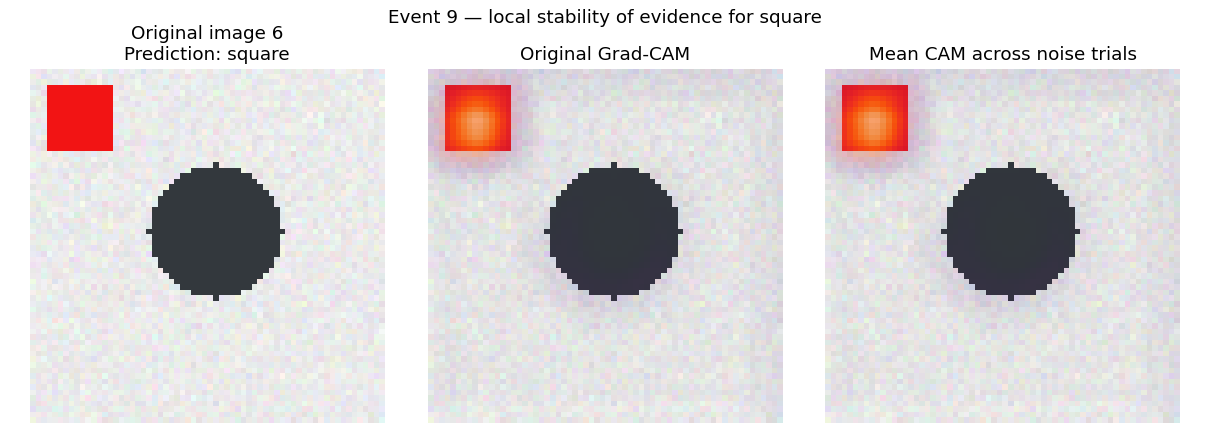

Image 6; explanation target: square; P = 0.980
Known label (retrospective check): circle
Five trials add Gaussian noise with standard deviation 0.01 on the [0, 1] pixel scale.
Stable predictions and heatmaps can consistently reflect a shortcut; stability is not proof of trustworthiness.
Grad-CAM does not estimate calibrated correctness probabilities or test robustness to marker changes.


In [4]:
# Event 9: assess trust using Grad-CAM and a small local stability check.
# Run the image setup and Event 7 first for the shared grad_cam helper.
idx9 = int(image_failure_case)
img9 = test_imgs[idx9]
cam9, probs9, target9 = grad_cam(image_model, img9, image_model.conv2)
names9 = ["circle", "square"]
corner9 = np.zeros(cam9.shape, dtype=bool)
corner9[3:15, 3:15] = True
shape9 = img9.max(axis=2) < 0.4
background9 = ~(corner9 | shape9)


def summarize_trust_trial(label, cam, probabilities):
    # Fix the explanation target to the original prediction for every trial.
    # Fixed masks describe the same regions despite small pixel perturbations.
    flat_base, flat_trial = cam9.ravel(), cam.ravel()
    correlation = (float(np.corrcoef(flat_base, flat_trial)[0, 1])
                   if flat_base.std() > 0 and flat_trial.std() > 0 else np.nan)
    return {
        "trial": label,
        "predicted class": names9[int(probabilities.argmax())],
        "P(original predicted class)": float(probabilities[target9]),
        "mean CAM: marker location": float(cam[corner9].mean()),
        "mean CAM: shape": float(cam[shape9].mean()),
        "mean CAM: background": float(cam[background9].mean()),
        "CAM correlation with original": correlation,
    }


rows9 = [summarize_trust_trial("original", cam9, probs9)]
noise_rng9 = np.random.default_rng(909)
perturbed_maps9 = []
for trial9 in range(5):
    # Small Gaussian pixel noise preserves the visible shape and marker.
    noisy9 = np.clip(img9 + noise_rng9.normal(0, 0.01, img9.shape), 0, 1).astype(np.float32)
    noisy_cam9, noisy_probs9, _ = grad_cam(
        image_model, noisy9, image_model.conv2, target_class=target9
    )
    perturbed_maps9.append(noisy_cam9)
    rows9.append(summarize_trust_trial(f"noise {trial9 + 1}", noisy_cam9, noisy_probs9))

event9_summary = pd.DataFrame(rows9)
print(f"Image {idx9}; explanation target: {names9[target9]}; P = {probs9[target9]:.3f}")
print(f"Known label (retrospective check): {names9[int(test_y[idx9])]}")
print("Five trials add Gaussian noise with standard deviation 0.01 on the [0, 1] pixel scale.")
display(event9_summary.round(4))
fig9, axes9 = plt.subplots(1, 3, figsize=(11, 4))
axes9[0].imshow(img9)
axes9[0].set_title(f"Original image {idx9}\nPrediction: {names9[target9]}")
for ax9, map9, title9 in [
    (axes9[1], cam9, "Original Grad-CAM"),
    (axes9[2], np.mean(perturbed_maps9, axis=0), "Mean CAM across noise trials"),
]:
    ax9.imshow(img9)
    ax9.imshow(map9, cmap="inferno", vmin=0, vmax=1, alpha=0.6 * map9)
    ax9.set_title(title9)
for ax9 in axes9:
    ax9.axis("off")
fig9.suptitle(f"Event 9 — local stability of evidence for {names9[target9]}")
fig9.tight_layout()
plt.show()
print("Stable predictions and heatmaps can consistently reflect a shortcut; stability is not proof of trustworthiness.")
print("Grad-CAM does not estimate calibrated correctness probabilities or test robustness to marker changes.")


### Event 9: Analysis of trustworthiness

**Output:** Grad-CAM for the original image and five versions with small Gaussian pixel noise (standard deviation 0.01 on the [0, 1] scale), a summary table, and overlays comparing the original map with the mean perturbed map. Every map targets the original predicted class, square, so the stability comparison uses a consistent target. These results describe the executed run; rerunning training may change them.

**Claim:** A human should not accept this square prediction as a reliable judgment of shape. Its high confidence and stable explanation do not overcome the suspicious concentration of evidence on the red marker.

**Evidence from the explanation:** In the original image, mean normalized Grad-CAM intensity is **0.712** at the marker, versus **0.119** inside the shape and **0.082** in the background. The marker-centered hotspot is unrelated to the intended geometric distinction between circles and squares. It therefore raises a concrete concern that the model is using a shortcut. This is a reason to question the prediction even before consulting the known label.

**Stability check:** All five noise trials retain the square prediction. Its probability stays approximately **0.9803–0.9805**, compared with **0.9801** originally. The perturbed maps have correlations above **0.9999** with the original map and continue to highlight the marker. Thus, this limited test finds stable predictions and stable spatial evidence, but the evidence remains suspicious. Consistency under tiny pixel changes is not the same as correctness or robustness to changes in the shortcut itself.

**Retrospective correctness check:** The known label is **circle**, confirming that this particular prediction is wrong despite its reported square probability of about 0.980. That label supplies external validation; it is not information discovered by Grad-CAM. A single confident error also does not measure the model's overall calibration or accuracy.

**What the method cannot establish:** Grad-CAM is not a calibrated confidence estimate and cannot provide the probability that this prediction is correct. These heatmaps do not prove causal reliance on the marker, and five nearby noise samples do not establish general robustness. Normalized heatmap values are not percentages of prediction responsibility. More evidence would require controlled marker changes, evaluation across representative cases with different marker–shape combinations, and calibration analysis. None of those broader checks is performed here.

**Medal: Silver.** Grad-CAM gives a specific, interpretable reason to withhold trust, and the local stability check shows why explanation consistency alone is insufficient. It offers useful partial evidence for a human judgment, rather than a complete or quantitative assessment of trustworthiness.


## Event 10: Reverse Engineer the Model

**Question:** What strategy has each model learned?

**Target:** Both target models

**Your task:** Synthesize evidence across events. A single output is usually not enough; explain what your method revealed and what remains unknown.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

### Event 10: Synthesis of the models' learned strategies

**Output:** A synthesis of the saved Grad-CAM results from Events 7–9 and the applicability assessment in Event 6. This event reuses those observations rather than running another explanation. Events 1–5 remain uncompleted in this notebook and are not treated as evidence here.

**Tabular model strategy:** Grad-CAM cannot establish what strategy `risk_model` learned. This random forest lacks the convolutional feature maps and differentiable class-score computation required by the method. Consequently, our analysis supplies no Grad-CAM evidence about its feature rankings, response curves, local decision rules, interactions, or use of proxy variables. Event 6's DNF is a limitation of the method, not evidence that the model has no interactions. The data generator's explicit rules also do not establish which rules the fitted random forest actually learned.

**Image model strategy:** The observed evidence is consistent with a shortcut in which the red corner marker supports the square class, even when the central shape is a circle. We can support this as a hypothesis about the examined cases, but cannot recover the CNN's complete strategy or conclude that it never uses shape information.

| Prior evidence | Observation | What it supports |
|---|---|---|
| Event 7: three marker-present cases | All are predicted as square, including two circles. Within each map, the marker has much higher mean CAM intensity (0.701–0.715) than the shape (0.068–0.130). | The square-class explanations consistently localize positive evidence to the marker across these selected cases. |
| Event 7: marker-absent square | Predicted as circle with probability 0.934; its circle-class map highlights shape edges and image borders diffusely. Regional means are close. | Consistent with the shortcut hypothesis, but insufficient to infer a general “no marker means circle” rule or prove that marker absence caused the error. |
| Event 8: assigned failure | A circle is predicted as square with probability 0.980, with a marker-centered square-class map and a blank circle-class map. | A plausible shortcut-related failure; the blank map means no positive localization from this Grad-CAM calculation, not absence of all shape information. |
| Event 9: five small-noise trials | The same failure remains a square prediction near probability 0.980, with nearly unchanged marker-centered maps. | The observed behavior is locally stable under these noise perturbations; that stability does not make the behavior correct or generally robust. |

**Evidence quality:** The strongest finding is the repeated spatial localization at the marker in the square-class maps. Combining this with the observed predictions and labels makes shortcut use a plausible explanation. However, Events 8 and 9 revisit the same failure image already included in Event 7: they deepen the analysis of that case rather than adding independent examples. The four assigned images are deliberately selected probes, not a representative estimate of how often the model uses a shortcut across the dataset. Comparisons between different images also change shape, background, and position, so they do not isolate the marker's causal effect.

**What remains unknown:** Grad-CAM cannot quantify the marker's causal contribution, recover exact decision rules, or establish whether shape information dominates in other images. The maps retain positive evidence only, depend on the chosen layer and class, and are normalized separately. Image-model hypotheses could be tested using matched marker-present and marker-absent versions of the same images, evaluated across many shapes and positions, along with prediction and error rates for each marker–shape group. Tabular strategy would require a compatible method, such as feature attribution and feature-effect/interaction analyses. These additional analyses have not been performed here.

**Medal: Silver overall.** Grad-CAM supports a useful partial profile of the image model's strategy through repeated marker localization, failure analysis, and a limited stability check. It cannot establish the full image-model strategy and provides no strategy explanation for the tabular target, so it does not fully answer the question about both models.


# Final Model Profile

After all ten events, write a short synthesis.

**Tabular model strategy:**  
Which features seem important? Did you find global effects, local effects, interactions, or suspicious proxies? What can your method support?

**Image model strategy:**  
Does the classifier appear to use the shape, the red marker, or both? What evidence supports that claim?

**Your method's decathlon profile:**  
Where did your method perform well? Where did it fail? What kind of explanation question is it best suited for?

**Open questions:**  
What would you want to compare with classmates who used other methods?
